In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df_9c = pd.read_pickle("../../Data_Processing/outputs/df_y9c.pickle")
df_parent = pd.read_pickle(r"../../Data_Processing/outputs/df_parent.pickle")

In [4]:
df_all = pd.concat([df_9c, df_parent], axis=0).reset_index(drop=True)

## Nr Holdings, SP and LP banks over time

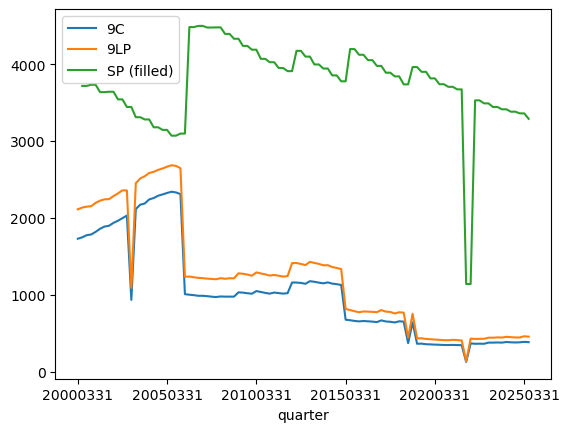

In [5]:
import matplotlib.pyplot as plt

# Base series
df_9c.groupby("quarter")["id"].nunique().plot(label="9C")
df_parent[df_parent["report_type"].str.contains("FRY9LP")].groupby("quarter")[
    "id"
].nunique().plot(label="9LP")

# SP — forward-fill to quarters 3 & 9
sp = (
    df_parent[
        df_parent["report_type"].str.contains("FRY9SP")
        & df_parent["month"].isin([6, 12])
    ]
    .groupby("quarter")["id"]
    .nunique()
    .reindex(sorted(df_parent["quarter"].unique()))  # ensure all quarters exist
    .ffill()  # fill 3 with 12, and fill 9 with 6
)

sp.plot(label="SP (filled)")

plt.legend()
plt.show()

## Overall revenue

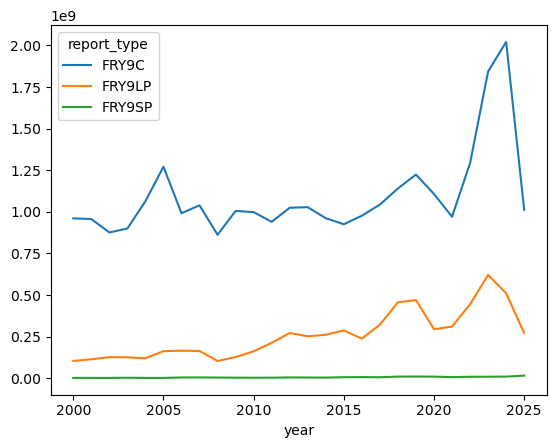

In [6]:
df_all.groupby(["year", "report_type"])["REVENUE"].sum().unstack().loc[
    :, ["FRY9C", "FRY9LP", "FRY9SP"]
].plot()
plt.show()

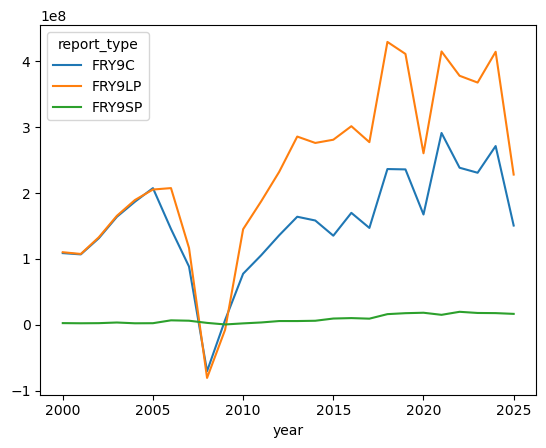

In [7]:
df_all.groupby(["year", "report_type"])["NET_INCOME"].sum().unstack().loc[
    :, ["FRY9C", "FRY9LP", "FRY9SP"]
].plot()
plt.show()

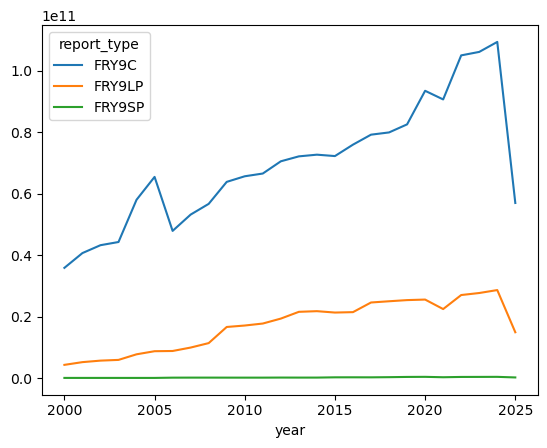

In [8]:
df_all.groupby(["year", "report_type"])["TOTAL_ASSETS"].sum().unstack().loc[
    :, ["FRY9C", "FRY9LP", "FRY9SP"]
].plot()
plt.show()

## Revenue evolution of 9c

<Axes: xlabel='quarter'>

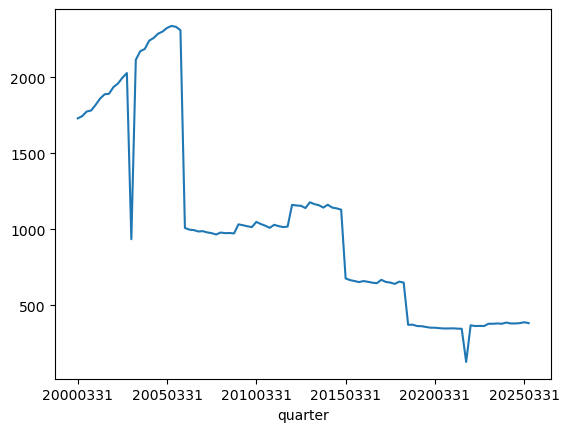

In [ ]:
df_9c.groupby("quarter")["id"].nunique().plot()

<Axes: >

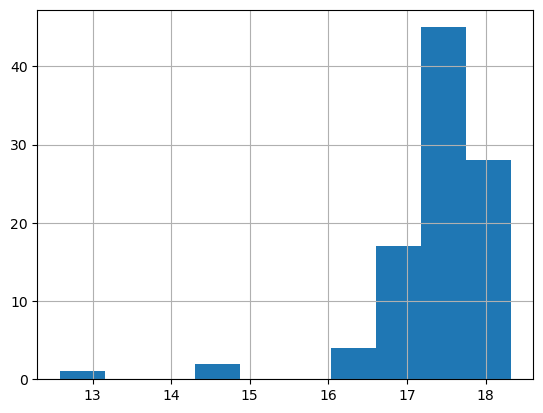

In [ ]:
df_9c.groupby("quarter")["NET_INCOME"].sum().apply(np.log).hist()

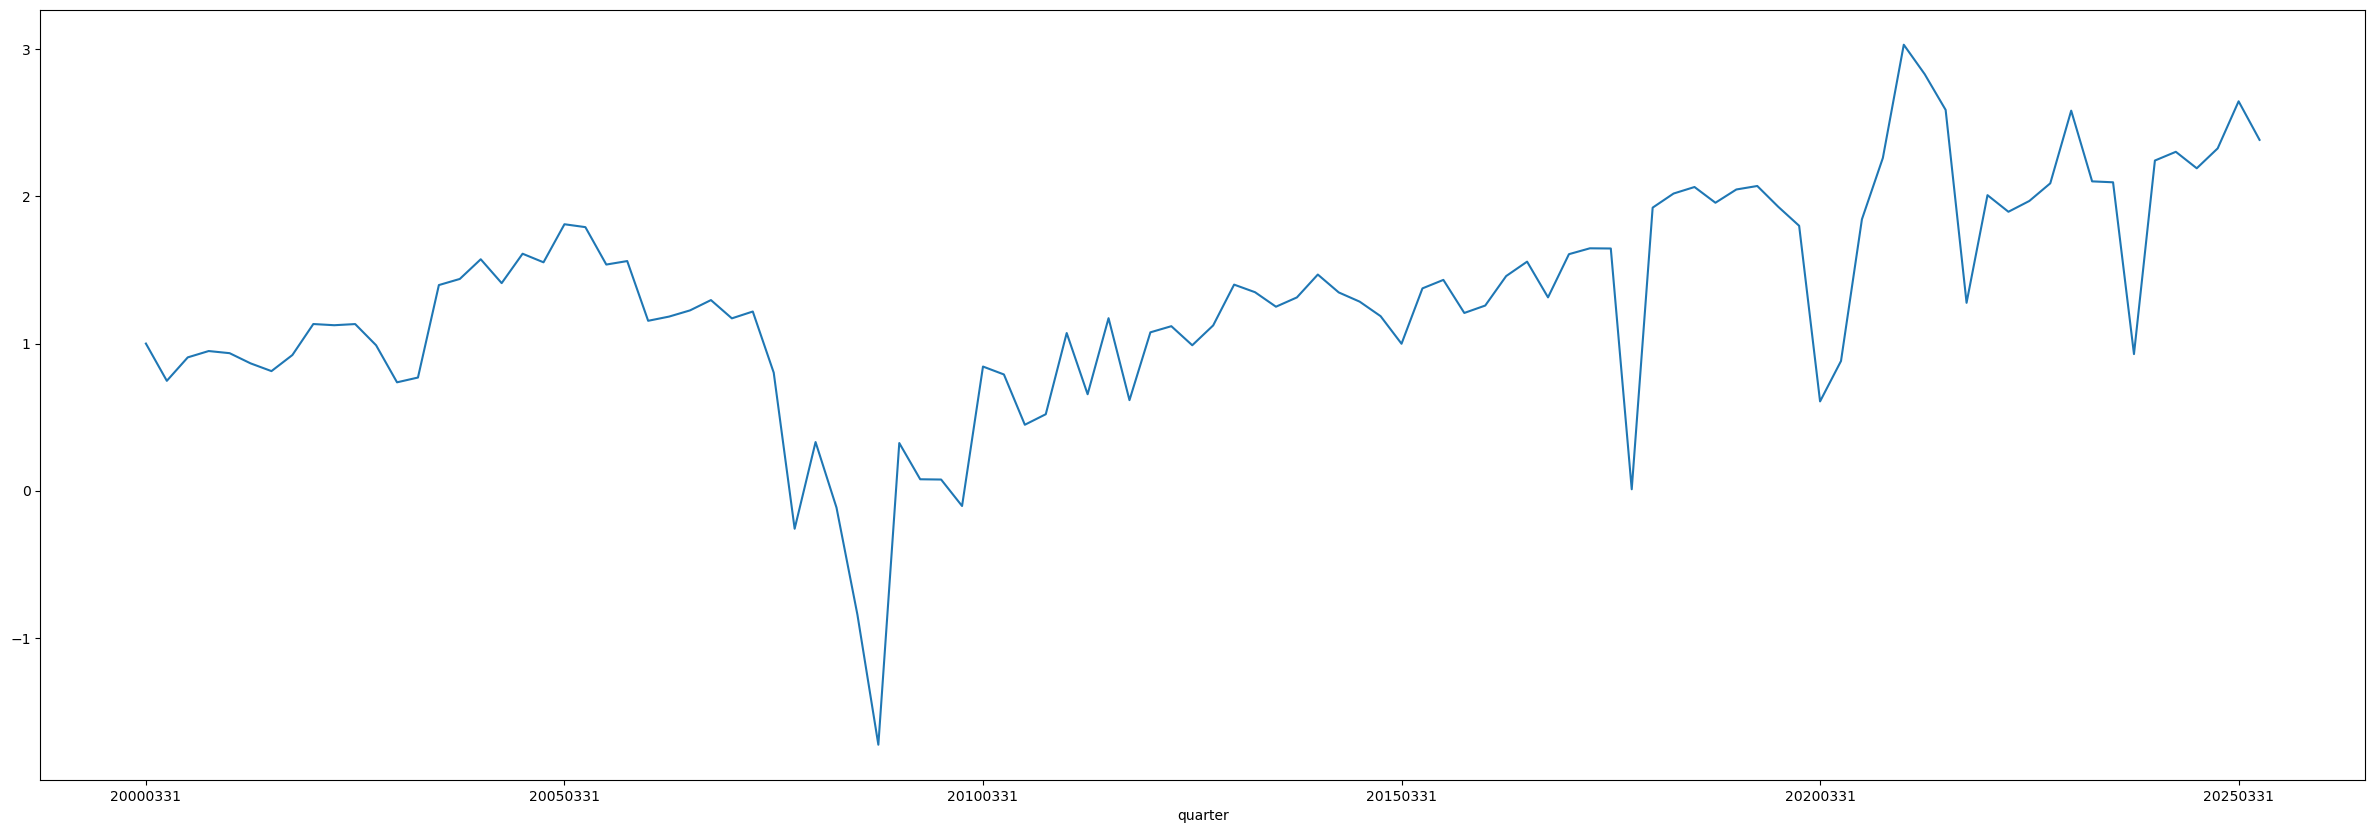

In [ ]:
(
    df_9c.groupby("quarter")["NET_INCOME"].sum()
    / df_9c.groupby("quarter")["NET_INCOME"].sum().iloc[0]
).plot(figsize=(30, 10))
plt.show()

<Axes: >

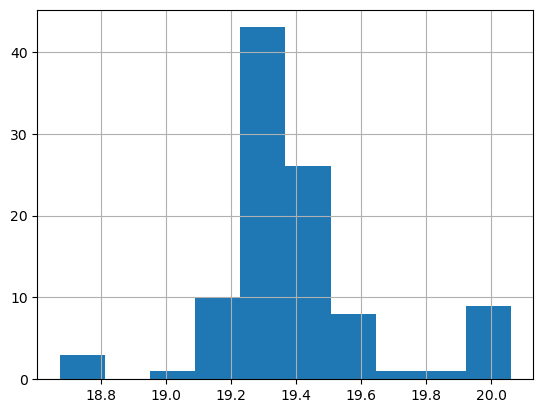

In [ ]:
df_9c.groupby("quarter")["REVENUE"].sum().apply(np.log).hist()

In [35]:
import matplotlib.pyplot as plt

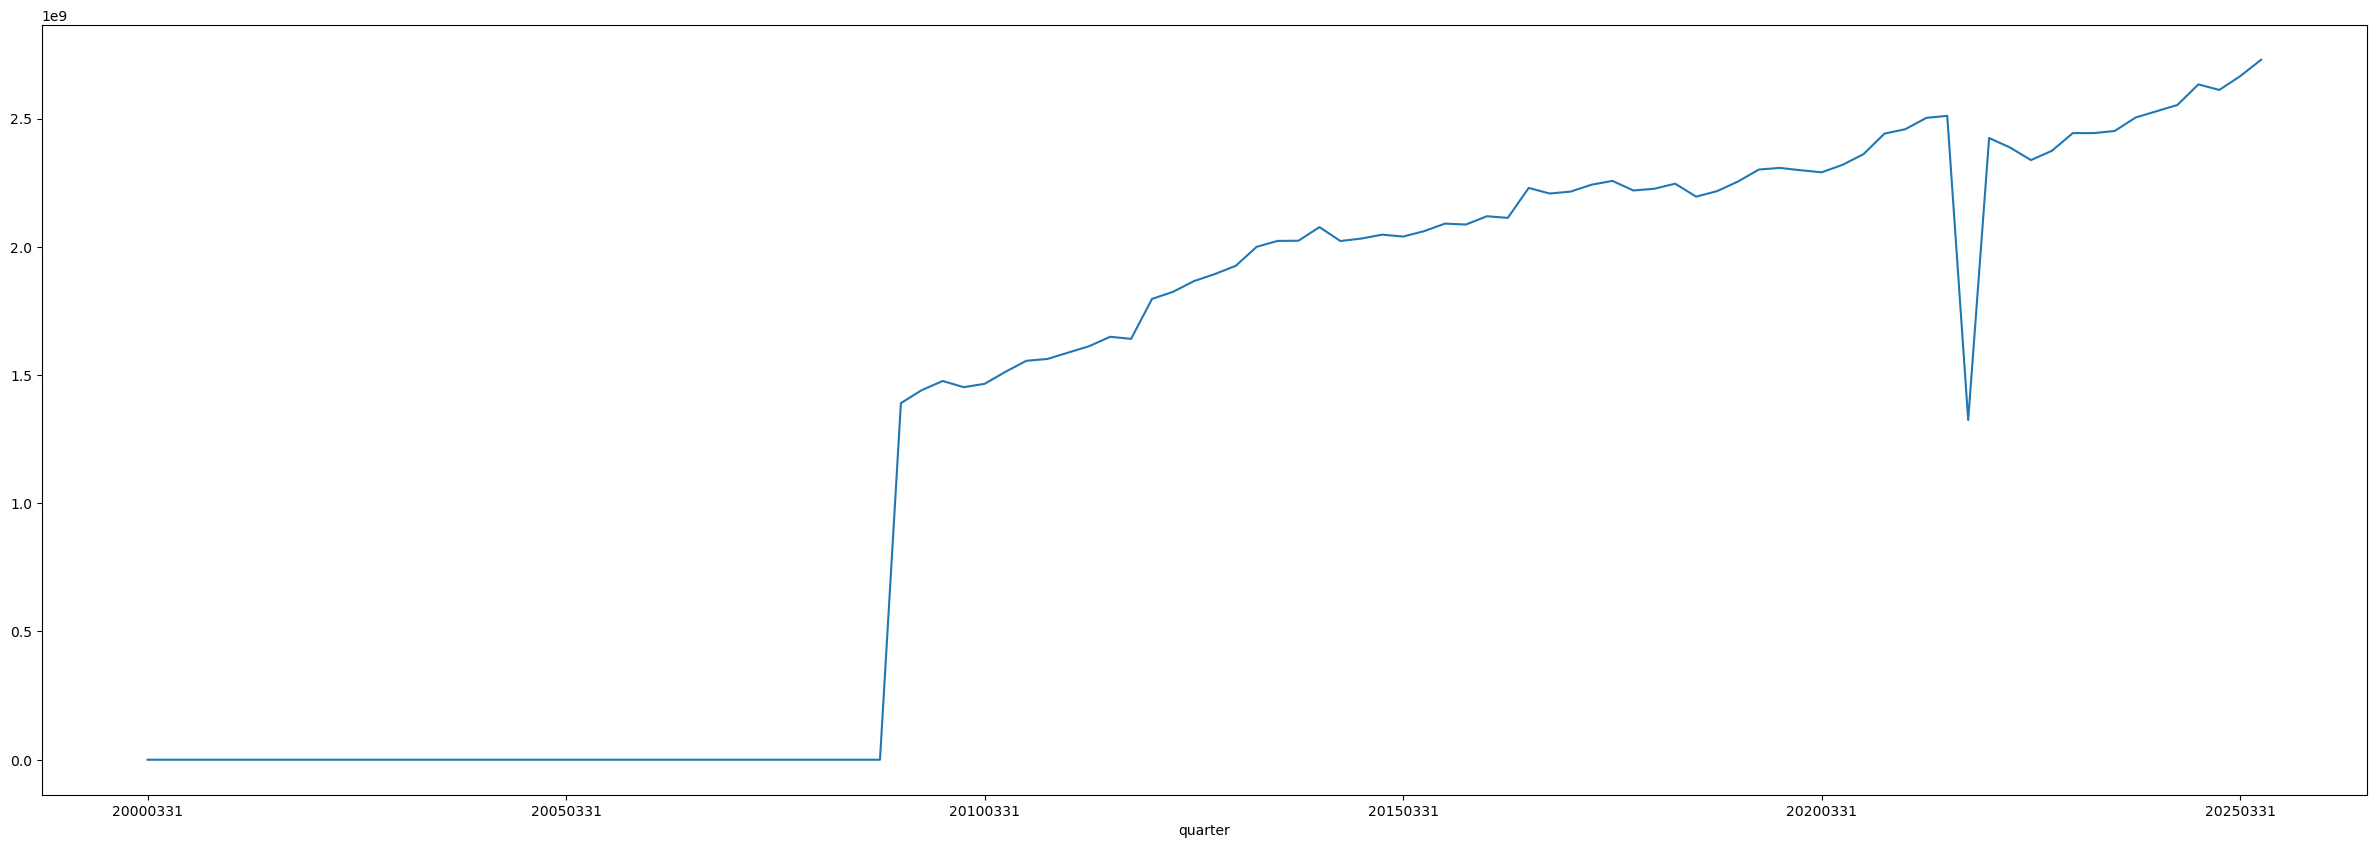

In [ ]:
(
    df_9c.groupby("quarter")["REVENUE"].sum()
    / df_9c.groupby("quarter")["REVENUE"].sum().iloc[0]
).plot(figsize=(30, 10))
plt.show()

In [ ]:
df_9c["CHARGED_OFF_TOTAL"] = df_9c[
    [col for col in df_9c.columns if "CHARGE" in col]
].sum(axis=1)
df_9c["RECOVERIES_TOTAL"] = df_9c[
    [col for col in df_9c.columns if "RECOVERIES" in col]
].sum(axis=1)

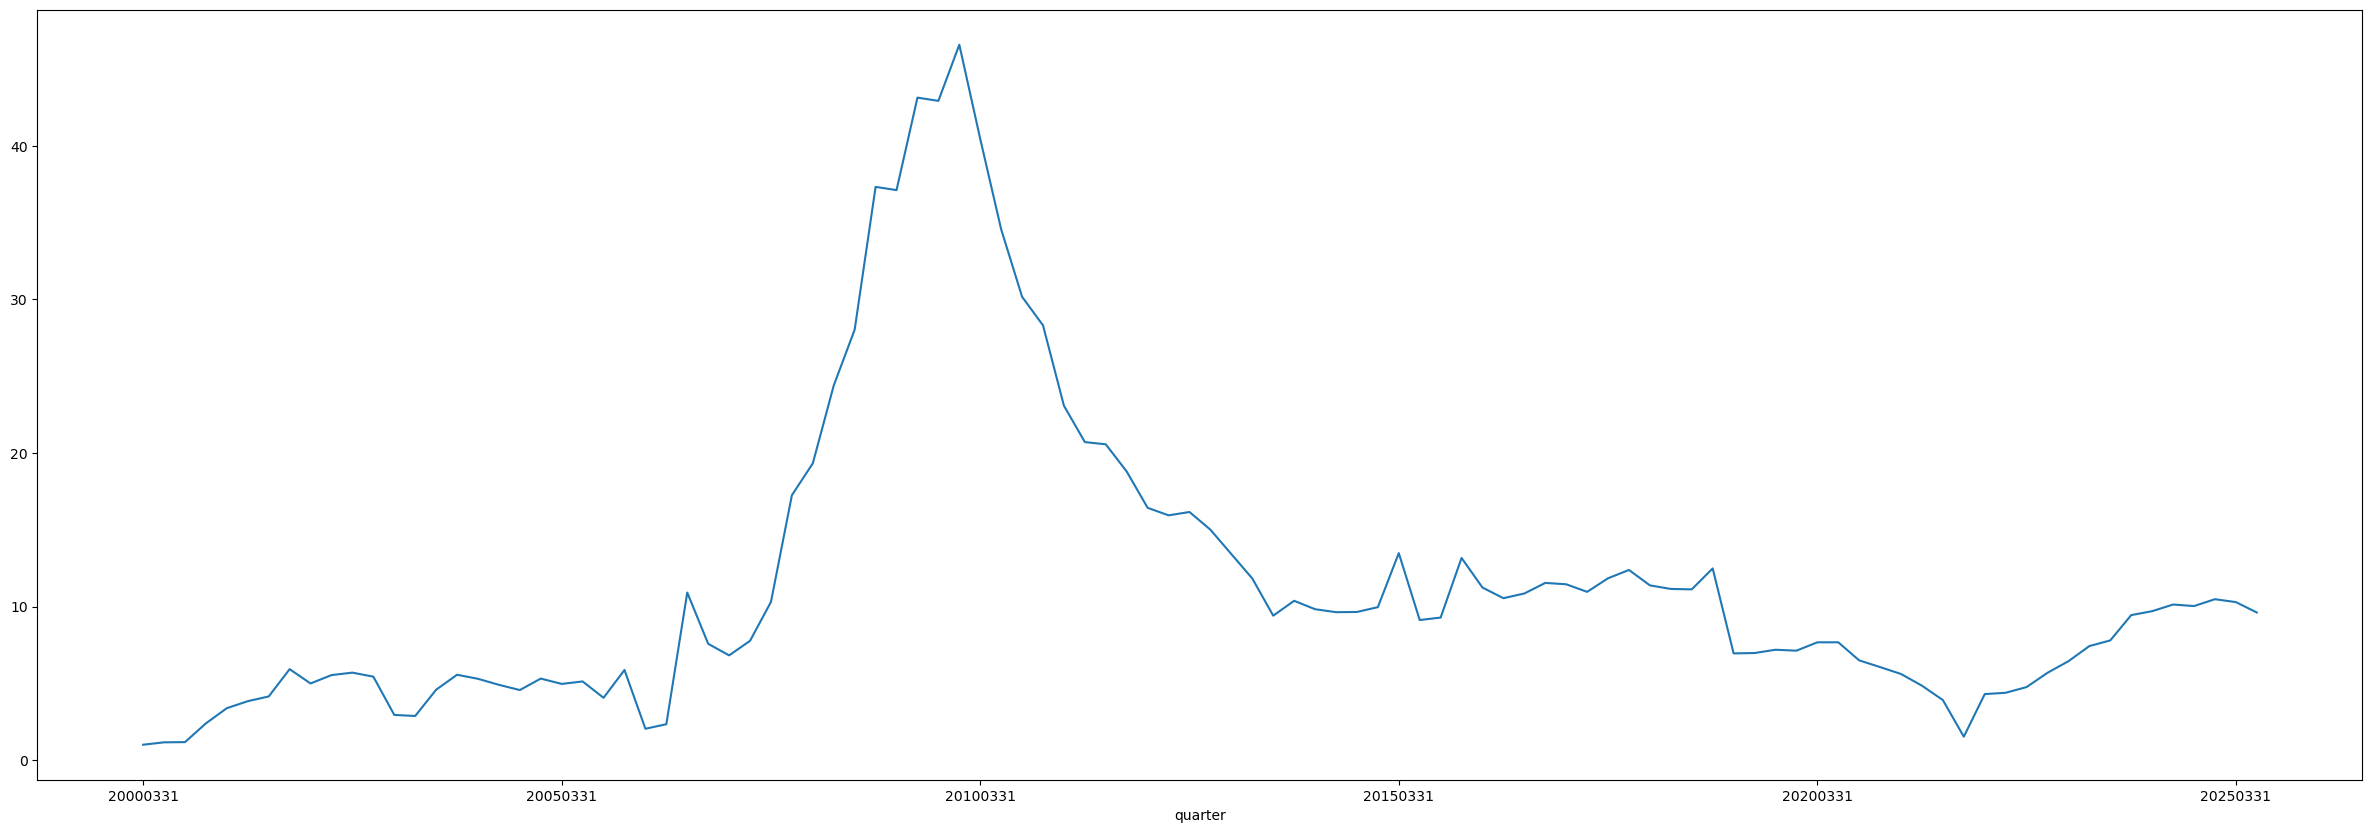

In [ ]:
(
    df_9c.groupby("quarter")["CHARGED_OFF_TOTAL"].sum()
    / df_9c.groupby("quarter")["CHARGED_OFF_TOTAL"].sum().iloc[0]
).plot(figsize=(30, 10))
plt.show()

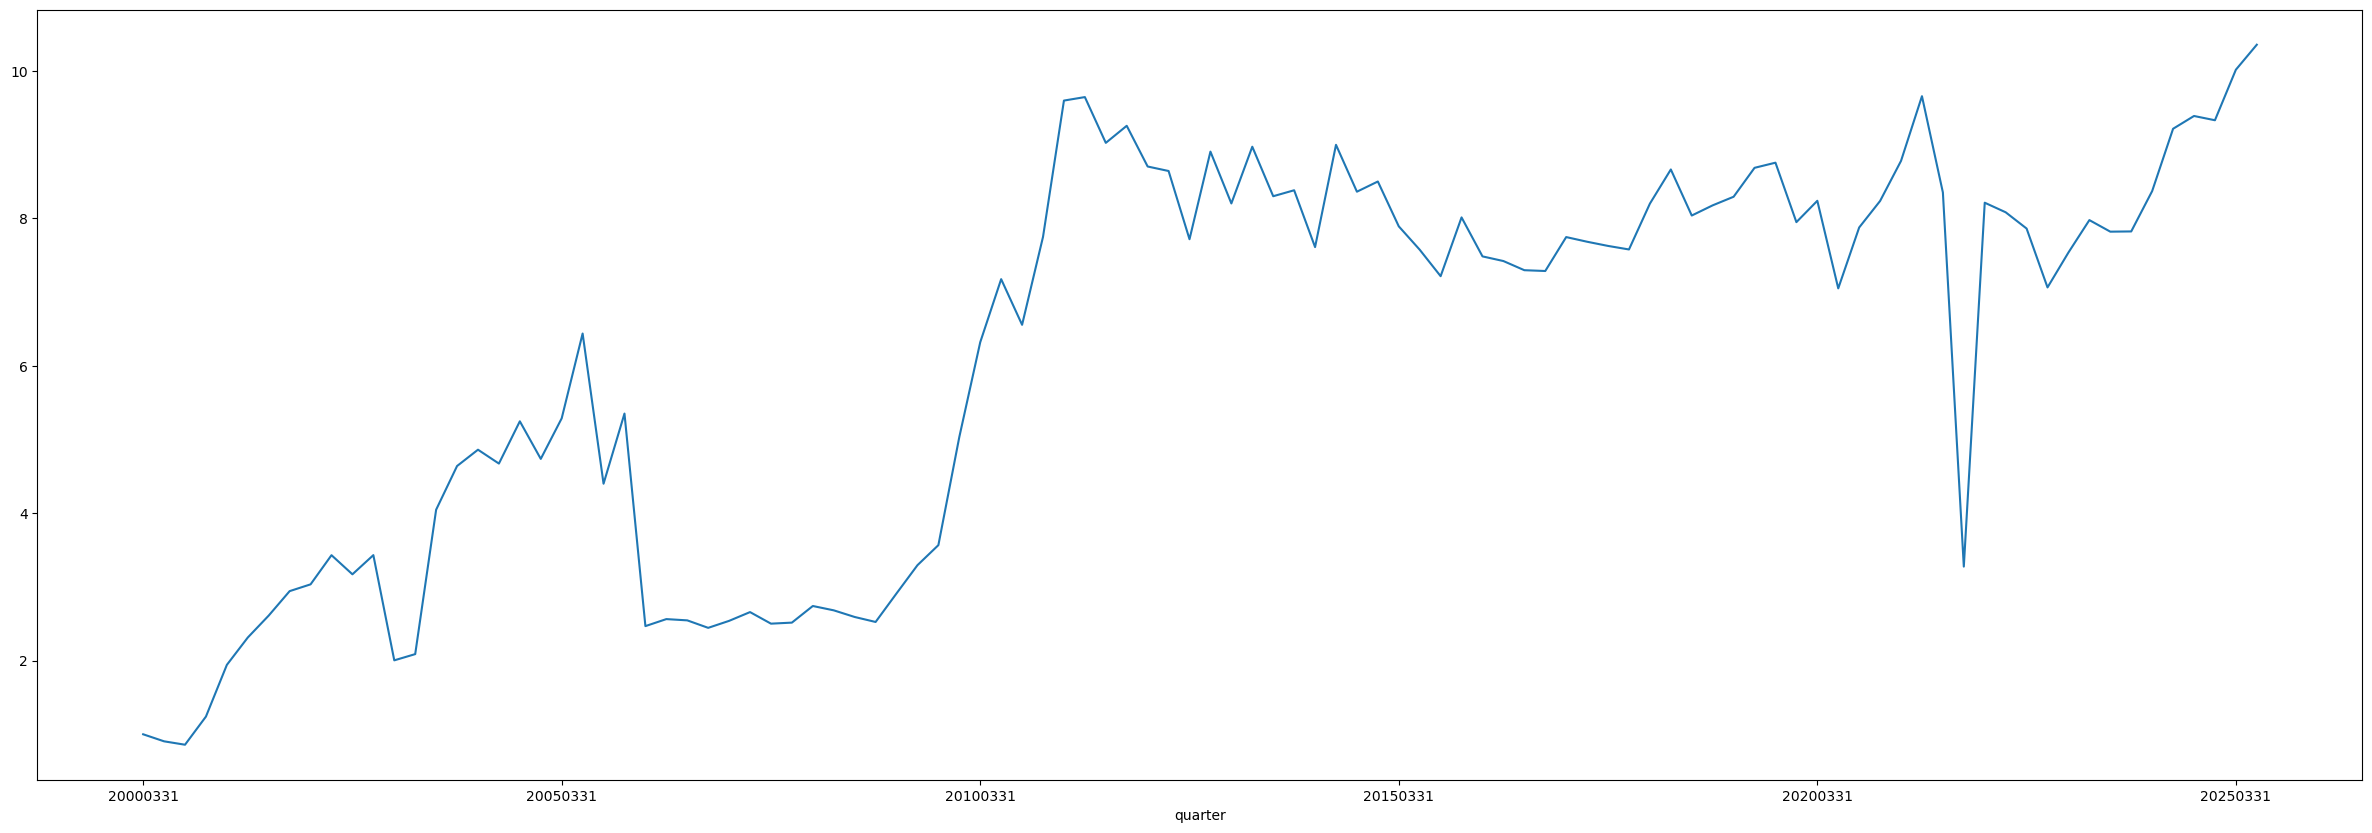

In [ ]:
(
    df_9c.groupby("quarter")["RECOVERIES_TOTAL"].sum()
    / df_9c.groupby("quarter")["RECOVERIES_TOTAL"].sum().iloc[0]
).plot(figsize=(30, 10))
plt.show()

In [ ]:
df_9c["LOANS_TOTAL"] = df_9c[
    [col for col in df_9c.columns if "ASSETS_LOANS" in col]
].sum(axis=1)

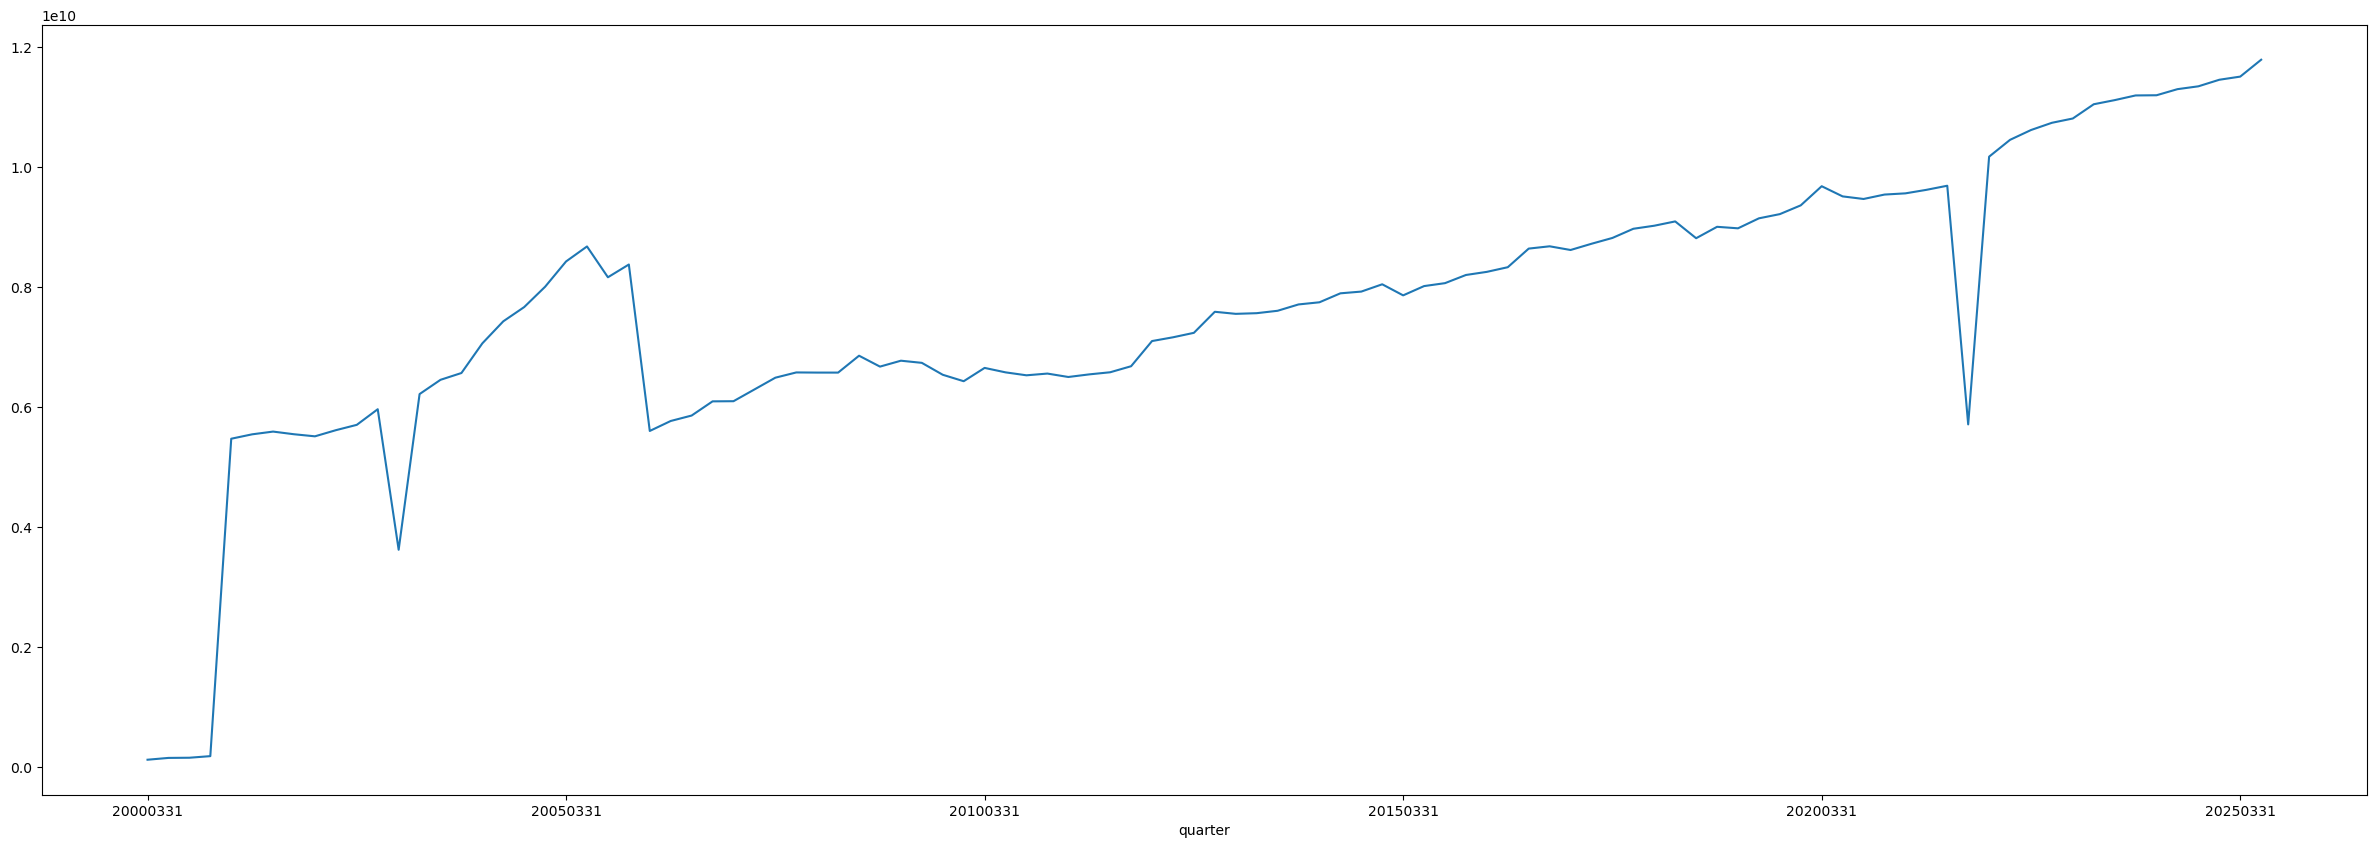

In [ ]:
(df_9c.groupby("quarter")["LOANS_TOTAL"].sum()).plot(figsize=(30, 10))
plt.show()

In [50]:
df_9c.columns

Index(['id', 'country', 'legal_name', 'quarter', 'REVENUE', 'NET_INCOME',
       'TOTAL_ASSETS', 'TOTAL_EQUITY', 'EBT', 'CAPITAL_TIER12',
       'ASSETS_CASH_NONINTERESTBALANCES',
       'ASSETS_CASH_INTERESTBALANCES_DOMESTIC',
       'ASSETS_CASH_INTERESTBALANCES_FOREIGN',
       'ASSETS_SECURITIES_HELDTOMATURITY', 'ASSETS_SECURITIES_AVAILABLESALE',
       'ASSETS_INVESTMENTS_SUBSIDIARIES', 'ASSETS_INTANGIBLEASSETS',
       'ASSETS_FIXEDASSETS', 'ASSETS_OTHERREALESTATE', 'ASSETS_OTHERASSETS',
       'ASSETS_TRADINGASSETS', 'ASSETS_INVESTMENTS_REALESTATE',
       'ASSETS_LOANSRECEIVABLES_SALE', 'ASSETS_LOANSRECEIVABLES_INVESTMENT',
       'ASSETS_FEDERALFUNDS_DOMESTIC', 'ASSETS_FEDERALFUNDS_RESELL',
       'ASSETS_SECURITIES_NOTFORTRADING', 'LOANS_LOSS_PROVISIONS',
       'CHARGED_OFF_REAL_ESTATE', 'CHARGED_OFF_FARMERS',
       'CHARGED_OFF_COMMERCE_INDUSTRY', 'CHARGED_OFF_HOUSEHOLDS',
       'CHARGED_OFF_FOREIGN_GOV', 'CHARGED_OFF_LEASE_FINANCING',
       'RECOVERIES_REAL_ESTATE', 'RE

<Axes: >

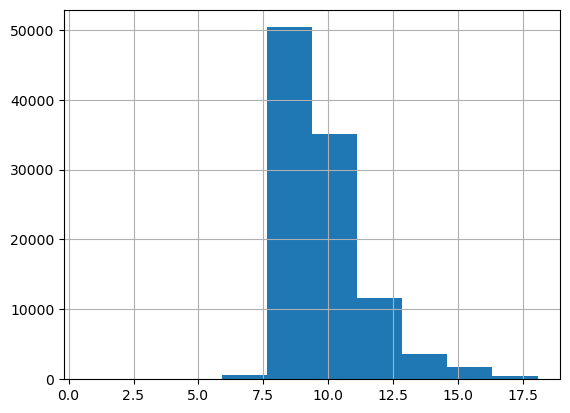

In [ ]:
df_9c[df_9c["REVENUE"] != 0]["REVENUE"].abs().apply(np.log).hist()

<Axes: >

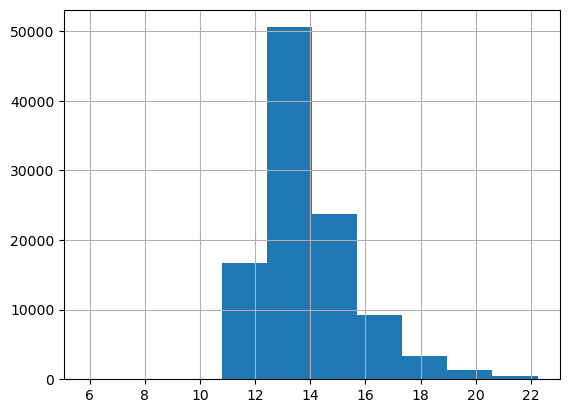

In [ ]:
df_9c["TOTAL_ASSETS"].apply(np.log).hist()

## Parent companies

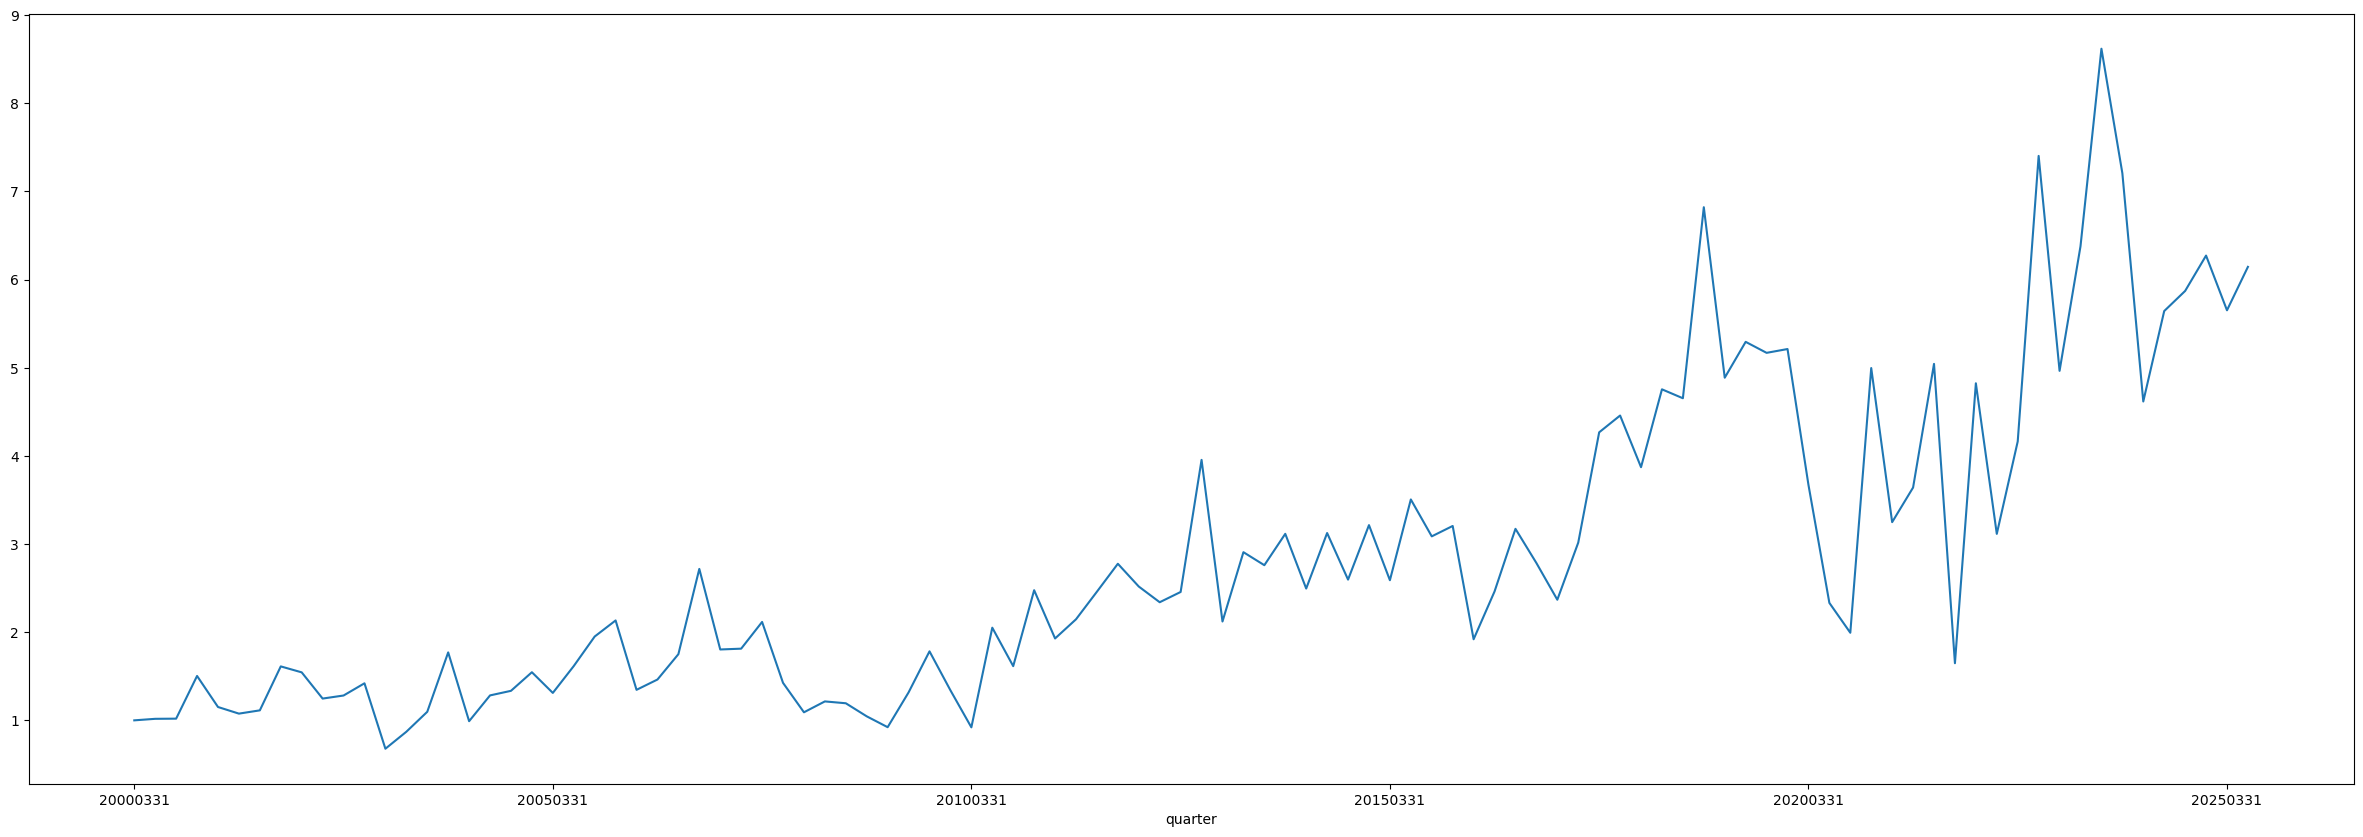

In [ ]:
(
    df_parent.groupby("quarter")["REVENUE"].sum()
    / df_parent.groupby("quarter")["REVENUE"].sum().iloc[0]
).plot(figsize=(30, 10))
plt.show()

<Axes: xlabel='quarter'>

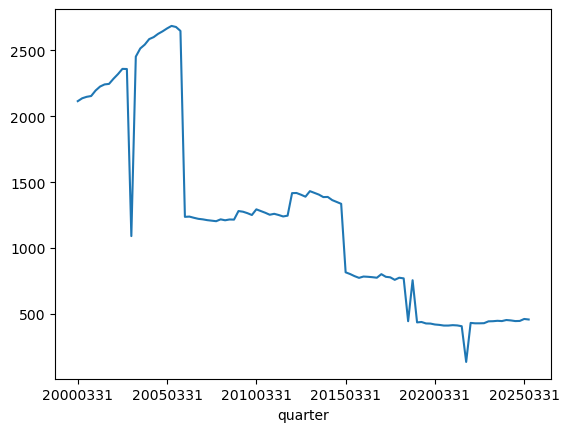

In [ ]:
df_parent[df_parent["report_type"].str.contains("FRY9LP")].groupby("quarter")[
    "id"
].nunique().plot()

<Axes: xlabel='quarter'>

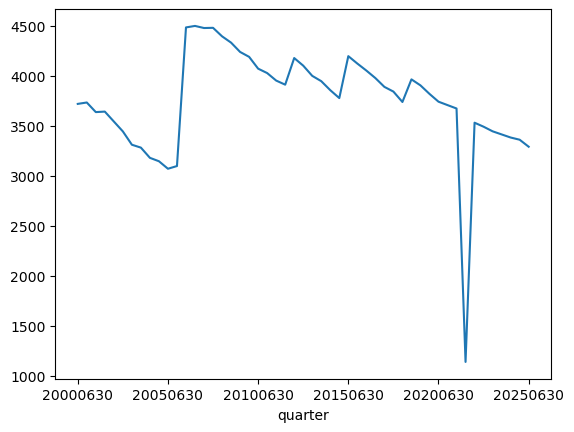

In [ ]:
df_parent[
    (df_parent["report_type"].str.contains("FRY9SP"))
    & (df_parent["month"].isin([6, 12]))
].groupby("quarter")["id"].nunique().plot()

In [ ]:
def transform_log(val):
    val = val.astype(float)  # ensure numeric
    out = np.zeros_like(val)

    out[val < 0] = -np.log(np.abs(val[val < 0]))
    out[val > 0] = np.log(val[val > 0])
    out[val == 0] = np.nan

    return out

In [ ]:
df_all = pd.concat([df_9c, df_parent], axis=0).reset_index(drop=True)

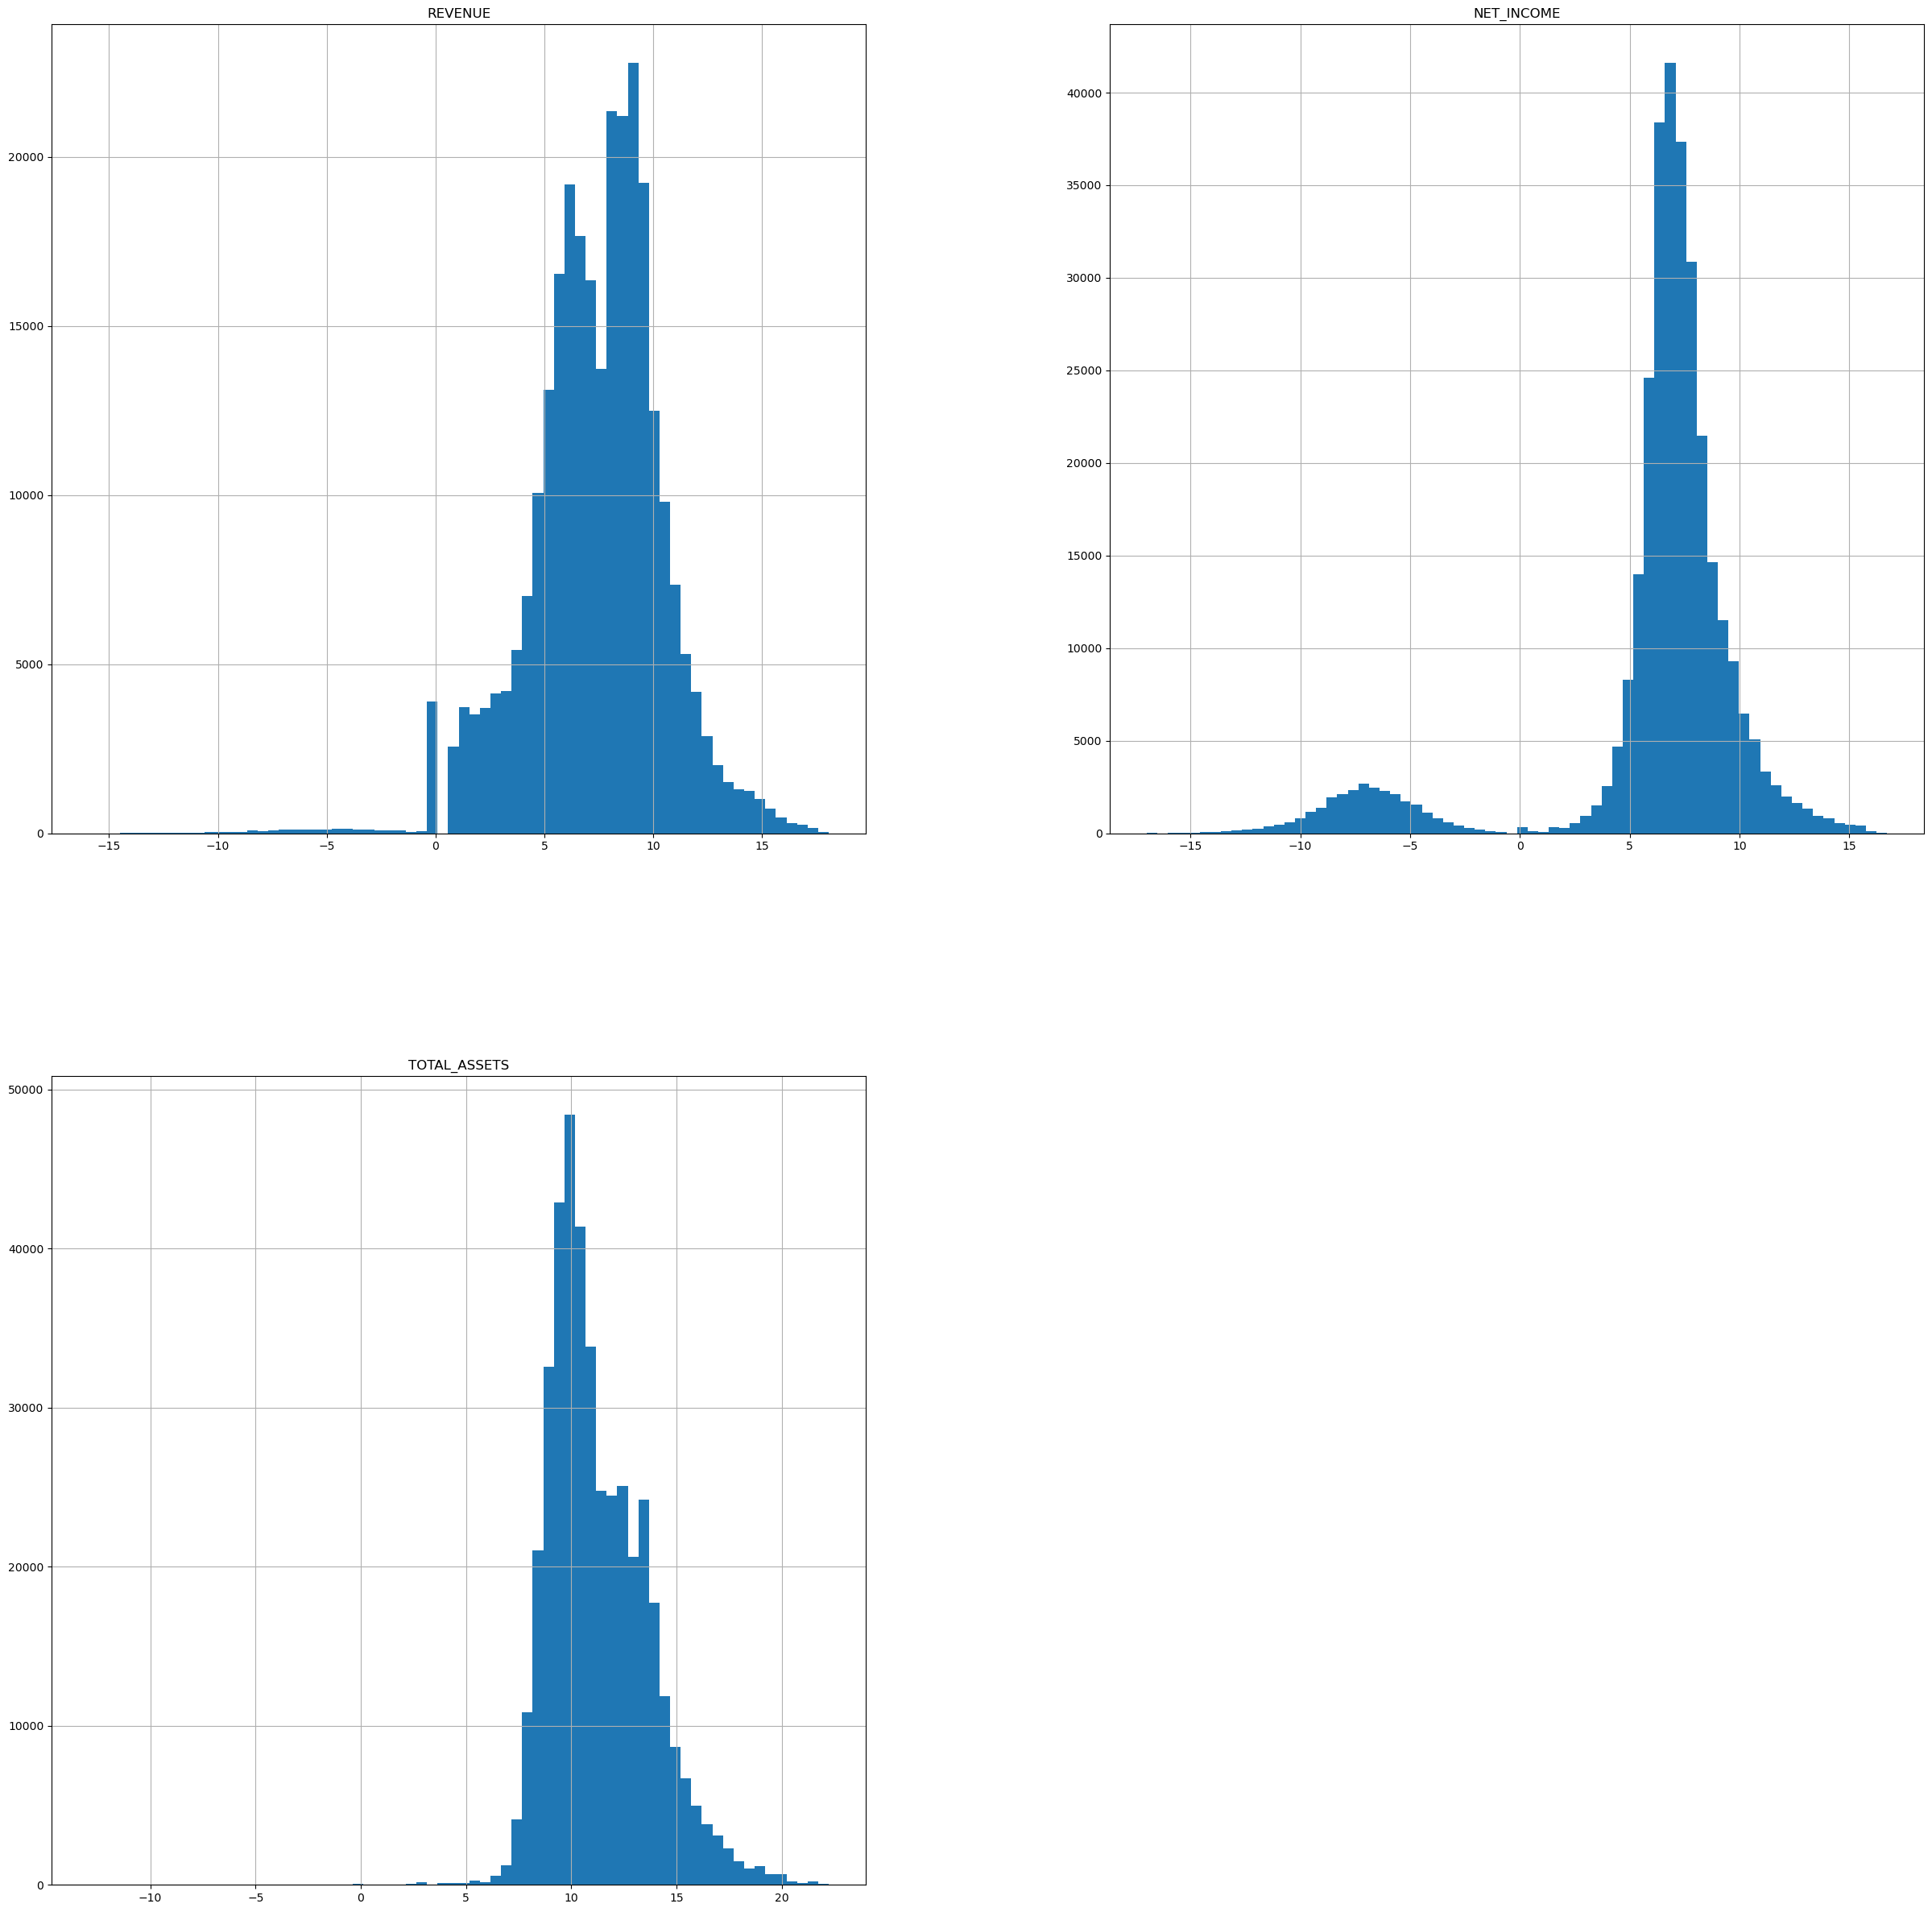

In [ ]:
df_all.loc[
    :,
    [
        col
        for col in df_9c.columns
        if col.upper() == col and col in ["NET_INCOME", "TOTAL_ASSETS", "REVENUE"]
    ],
].apply(transform_log).hist(figsize=(30, 30), bins=70)
plt.show()

In [ ]:
ax = df_9c.groupby("quarter")["TOTAL_ASSETS"].sum().plot(figsize=(30, 5))

quarters = df_9c["quarter"].unique()
tick_positions = range(len(quarters))

ax.set_xticks(tick_positions)  # more ticks
ax.set_xticklabels(quarters, rotation=45)  # show quarter labels
plt.show()

In [ ]:
ax = df_9c.groupby("quarter")["REVENUE"].sum().plot(figsize=(30, 5))

quarters = df_9c["quarter"].unique()
tick_positions = range(len(quarters))

ax.set_xticks(tick_positions)  # more ticks
ax.set_xticklabels(quarters, rotation=45)  # show quarter labels
plt.show()